Applying a bayesian decoder to times when the mouse is stationary and seeing if we can find replay
- identify windows with 30% of active cells first

In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = {"JAL4_3rdSept": JAL4_3rdSept,
        "JAL4_19thSept": JAL4_19thSept,
        "JAL4_28aug": JAL4_28aug,
        "JAL4_11thSept": JAL4_11thSept,
        "JAL5_8thSept": JAL005_8thSept,
        "JAL5_21stSept": JAL005_21stSept,
        "JAL6_28mar": JAL6_28mar, 
        "JAL6_flip4_21mar": JAL6_flip4_21mar, 
        "JAL6_flip3_18mar": JAL6_flip3_18mar, 
        "JAL6_flip5_25mar": JAL6_flip5_25mar, 
        "JAL7_sesh8_9apr": JAL7_sesh8_9apr, 
        "JAL7_flip5_22mar": JAL7_flip5_22mar, 
        "JAL7_flip2_12mar": JAL7_flip2_12mar, 
        "JAL7_sesh9_16apr": JAL7_sesh9_16apr, 
        "JAL7_23apr": JAL7_23apr,
        "JAL8_flip1_25apr": JAL8_flip1_25apr, 
        "JAL8_flip2_29apr": JAL8_flip2_29apr, 
        "JAL8_flip3_7may": JAL8_flip3_7may, 
        "JAL8_14may": JAL8_14may, 
        "JAL8_flip4_10may": JAL8_flip4_10may}

In [5]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.process.process import Process
from JR_test_scripts.escape.escape_utils import load_homing, load_hdir_cells, load_significant_cells
from JR_test_scripts.replay.BayesianReplay_funcs import bayesian_decoder, calculate_custom_replay_score, calculate_linear_weighted_correlation

import os
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from scipy.stats import zscore
from syd import make_viewer

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
"""Load the data"""
c_names = ['shelter_only', 'barrier', 'flipped_barrier']
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
explore_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/")
homie_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
save_path = make_directory("Z:/Jasmine_Laurence/summary_plots/Replay/PreHomingSorted")
tuning_data = '_25bins' # '' or '_50bins' or '_25bins
cond_colors = ['#228B22','#FF8C00','#008B8B']
homing_color = '#6A0DAD'
escape_color = '#E63946'

# which data?!
e = 7
session_name = list(experiments_objects.keys())[e]
exp = experiments_objects[session_name]
cond = 1

In [4]:
"""Load tuning data.
We need to identify significant cells and their tuning preference - build the template"""
sig_cells = load_significant_cells(exp, case = "either_tuned", tuning_data = tuning_data)
hdir = load_hdir_cells([exp], [session_name])
sig_cells[hdir,:] = np.full(3, False)

exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
data = np.load(homie_path + exp_nickname + '_ProperTuning' + tuning_data + '.npz')
sig_escape = data['params_real'][:,:,0] > np.nanpercentile(data['params_shifts'][:,:,:,0], 95, axis = 0)
preferred_tuning = data['params_full'][:,:,1] # preferred %escape for neurons in each condition

2025-04-28 15:50:22.085 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


In [6]:
"""Load frame by cluster matrix
This should probably be zscored!"""
session = Process(exp).load_session()
base_path = os.path.join(session.base_path, session.processed_path)

# matrix
frame_by_cluster_matrix = np.load(
    os.path.join(session.base_path, session.processed_path)
    + "\\"
    + "frame_by_good_cluster_matrix.npy"
)

# only keep timepoints in this condition
video_df = pl.read_csv(os.path.join(base_path, "full_video_dataframe.csv"))
bar = video_df["barrier_present"].to_numpy()
barflip = video_df["barrier_flipped"].to_numpy()
y_pos = video_df["mouse_y_position"].to_numpy()
x_pos = video_df["mouse_x_position"].to_numpy()
condition = np.zeros(len(bar))
condition[bar] += 1
condition[barflip] += 1

2025-04-28 15:50:57.105 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


In [7]:
"""Load the homing data"""
h_on, h_off, homing_bool = load_homing(session, int(np.amax(np.unique(video_df['frames'].to_numpy()))))

# booleans for homing+escape and explore
# TODO this is a hack into the escapes to remove the 1s of pause before they start running
escape = video_df['EscapePeriod'].to_numpy()
escape_bool = np.full_like(escape, False)
start = np.where(np.diff(escape.astype(int)) == 1)[0]
end = np.where(np.diff(escape.astype(int)) == -1)[0]
for s, e in zip(start, end):
    escape_bool[s+40:e] = True

h_e_bool = (homing_bool | escape_bool) & (video_df['OutofshelterIdx'].to_numpy())

2025-04-28 15:51:53.467 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


In [26]:
"""Time when the mouse is in the shelter in the selected condition"""
# only keep sig cells in this condition
# fcm = gaussian_filter1d(fcm[:,sig_cells[:,cond]], 2, axis = 0)
fcm = frame_by_cluster_matrix[:,sig_cells[:,cond]]

bool_mask = np.full(len(h_e_bool), True) # h_e_bool == False
bool_mask = np.logical_and(bool_mask, condition == cond)

# select condtion and sort by pref tuning
# fcm = fcm[bool_mask,:]
template_seq = np.argsort(preferred_tuning[sig_cells[:,cond],cond])
fcm = fcm[:,template_seq]

# zscore neural data, only for finding the windows!!
fcm_z = zscore(fcm, axis = 0) # time x neurons

In [38]:
"""Sliding window search
Over windows of 300ms, search for periods when 30% of cells are active (> 1 zscore?)"""
window_ms = 300
window_samples = int((window_ms/1000)*40)
step = int(((window_ms/1000)/3)*40) # step every 100ms
threshold = 2 # zscore threshold
frac_active = .4

identified_window = []
identified_num_active = []
activity = np.full(fcm.shape[0], False)

# loop through periods where bool_mask is true to find active windows
b_start = np.where(np.diff(bool_mask.astype(int)) == 1)[0]
b_end = np.where(np.diff(bool_mask.astype(int)) == -1)[0]
for s,e in zip(b_start, b_end):
    if e-s < window_samples:
        continue
    # check if there is a window of activity
    for i in range(s, e-window_samples, step):
        window = fcm_z[i:i+window_samples,:] > threshold
        time_over_t = np.sum(window, axis = 0) # number of timepoints above threshold
        num_active = np.sum(time_over_t > 0) # number of active cells
        # check if 30% of cells are active
        if num_active > (frac_active * window.shape[1]):
            activity[i:i+window_samples] = True
            identified_window.append(i)
            identified_num_active.append(num_active)


print(f"Found {len(identified_window)} windows of activity")

# there will be some consecutive windows with overlapping activity
# find consecutive windows, look at which one has the highest fraction of active cells
# only keep the one with the most active cells
# Step 1: Find breaks between consecutive windows
diff_window_time = np.diff(identified_window)
breaks = np.where(diff_window_time > 40)[0]
breaks = np.append(breaks, len(identified_window)-1)  # Add the last index

# Step 2: Process each group of consecutive windows
start_idx = 0
best_windows = [] # list of window start frames
best_activity = np.full(fcm.shape[0], False)  # Initialize best activity array

for end_idx in breaks:
    # Extract the current group of consecutive windows
    group = identified_window[start_idx:end_idx+1]
    
    if len(group) == 0:
        continue
        
    # Find the window with highest fraction of active cells in this group
    group_fractions = [identified_num_active[a] for win_idx in group for a,x, in enumerate(identified_window) if x == win_idx]
    best_window_idx = start_idx + np.argmax(group_fractions)
    
    # Keep only the best window from this group
    best_windows.append(identified_window[best_window_idx])

    # Update the best activity array
    best_activity[identified_window[best_window_idx]:identified_window[best_window_idx] + window_samples] = True
    
    # Move to the next group
    start_idx = end_idx + 1

# Convert to array for easier handling
best_windows = np.array(best_windows)
print(f"Found {len(best_windows)} windows of activity")

Found 167 windows of activity
Found 49 windows of activity


In [10]:
# pull out the data
firing_rate_maps = data['fr_full'][cond,sig_cells[:,cond],:] # tuning curves for each neuron
firing_rate_maps = firing_rate_maps[template_seq,:] # sort by pref tuning
# set up some variables
n_position_bins = firing_rate_maps.shape[1]
time_bin_width = 0.025  # 25 ms for a 40Hz frame rate
# Define position bins (replace with your actual bins)
max_fract = 100
position_bin_edges = np.linspace(0, max_fract, n_position_bins + 1)

# Define parameters
fract_thresh = 10.0 # Threshold of fraction of route in percent

# Define parameter search ranges (adjust based on expected replay speeds/positions)
# Velocity range (e.g., -10 m/s to +10 m/s, 101 steps) -> -1000 cm/s to 1000 cm/s
V_range = [-50, 50, 51]
# Starting position range (e.g., full track length, 100 steps)
rho_range = [0, max_fract, 100]

# Discretize the escape variable
occupancy_map = np.ones(n_position_bins) / n_position_bins # Uniform prior

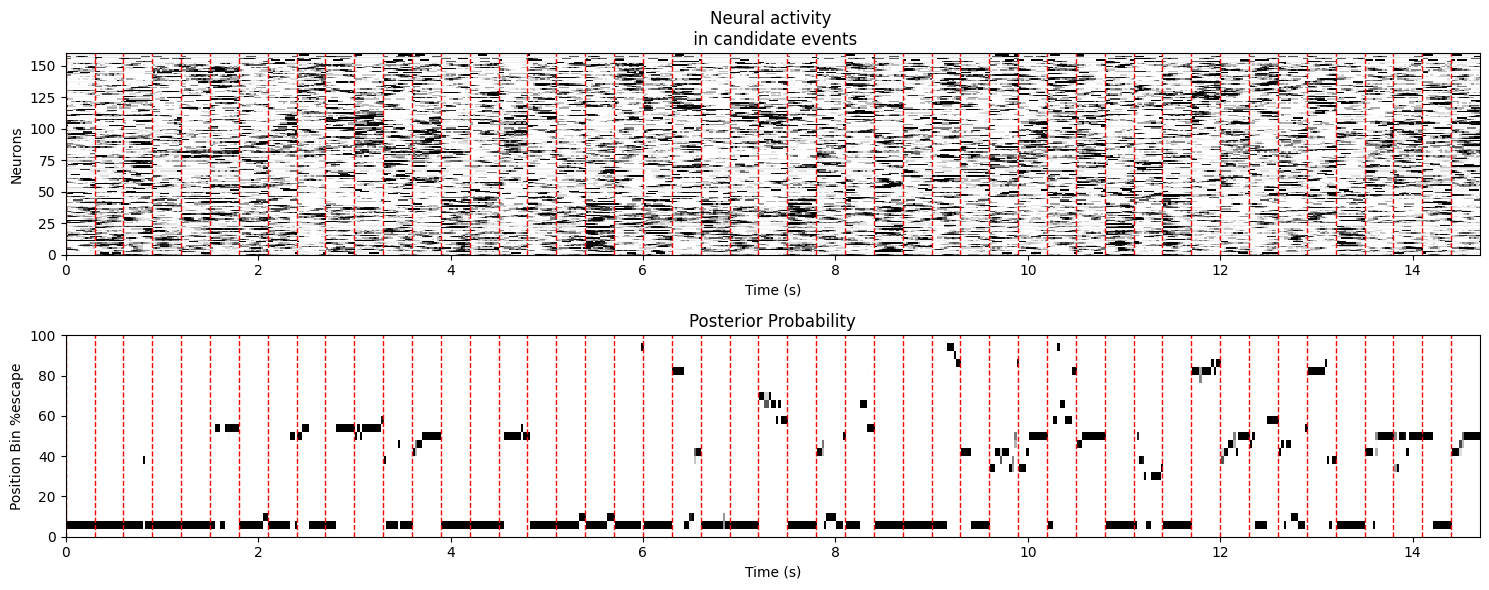

In [39]:
"""Make a plot of all the windows and the bayesian decoded position"""
fig, ax = plt.subplots(2, 1, figsize=(15, 6))
ax[0].imshow(zscore(fcm[best_activity,:], axis=0).T, vmin=-.5, vmax=1.5, aspect = 'auto', origin = 'lower', interpolation = 'none', cmap = 'Greys',
             extent=(0, fcm[best_activity,:].shape[0]/40, 0, fcm[best_activity,:].shape[1]))
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Neurons')
ax[0].set_title('Neural activity \n in candidate events')
for i in np.arange(0, np.sum(best_activity), window_samples):
    ax[0].axvline(i/40, color = 'red', linestyle = '--', linewidth = 1)

posterior = bayesian_decoder(firing_rate_maps, fcm[best_activity,:], occupancy_map, time_bin_width, fcm[best_activity,:].shape[0], n_position_bins)
ax[1].imshow(posterior.T, aspect='auto', origin='lower', interpolation='none', cmap = 'Greys',
             extent=[0, fcm[best_activity,:].shape[0]/40, 0, max_fract])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel(r'Position Bin %escape')
ax[1].set_title('Posterior Probability')
for i in np.arange(0, np.sum(best_activity), window_samples):
    ax[1].axvline(i/40, color = 'red', linestyle = '--', linewidth = 1)

plt.tight_layout()

In [82]:
"""Make a syd plot for each candidate event"""

def plot(state):
    # firing_rate_maps: A 2D array or list of arrays. Shape: (n_neurons, n_position_bins). Contains the average firing rate of each neuron i for each position bin x. These are the "templates".
    # spike_counts: A 2D array. Shape: (n_time_bins, n_neurons). Contains the number of spikes n_i detected for each neuron i within each time bin t of the candidate event.
    # occupancy_map: A 1D array. Shape: (n_position_bins,). Contains the normalized probability P(x) of the animal being in each position bin x, derived from overall session behavior.
    # time_bin_width (τ): A float. The duration of each time bin in seconds (e.g., 0.02 for 20ms).
    # n_neurons (N): An integer. The total number of neurons used for decoding.
    # n_position_bins: An integer. The number of spatial bins used to discretize the environment.
    # n_time_bins: An integer. The number of time bins in the candidate event window.

    spike_counts = fcm[best_windows[state['window idx']]:best_windows[state['window idx']]+window_samples,:]
    n_time_bins = spike_counts.shape[0]

    posterior = bayesian_decoder(firing_rate_maps, spike_counts, occupancy_map, time_bin_width, n_time_bins, n_position_bins)
    linear_corr = calculate_linear_weighted_correlation(posterior)
    R_max, V_max, rho_max, R_map = calculate_custom_replay_score(posterior, time_bin_width, position_bin_edges, fract_thresh, V_range, rho_range)

    # Plotting the results
    fig, ax = plt.subplots(1, 4, figsize=(15, 6))

    # show the tuning curves
    im = ax[0].imshow(zscore(firing_rate_maps, axis = 1), vmin=-.5, vmax=1.5, aspect = 'auto', cmap = 'Greys', interpolation = 'none',
                            extent=(0, max_fract, 0, firing_rate_maps.shape[0]))
    ax[0].set_xlabel(r'% escape')
    ax[0].set_ylabel('Neurons')
    ax[0].set_title(r'Tuning to %escape')

    # show the activity in the candidate event
    im = ax[1].imshow(zscore(spike_counts, axis = 0).T, vmin=-.5, vmax=1.5, aspect = 'auto', cmap = 'Greys', interpolation = 'none',
                            extent=(0, spike_counts.shape[0]/40, 0, spike_counts.shape[1]))
    ax[1].set_xlabel('Time (s)')
    ax[1].set_ylabel('Neurons')
    ax[1].set_title('Neural activity \n in homing&escapes')
    fig.colorbar(im, ax=ax[1], label='z-score')

    # show the posterior probability
    im = ax[2].imshow(posterior.T, aspect='auto', origin='lower', interpolation='nearest',
                    extent=[0, n_time_bins * time_bin_width, 0, max_fract])
    ax[2].set_xlabel('Time (s)')
    ax[2].set_ylabel(r'Position Bin %escape')
    ax[2].set_title('Posterior Probability' + '\n' + f"Linear Correlation: {linear_corr:.2f}")
    fig.colorbar(im, ax=ax[2], label='Posterior Probability')
    plt.tight_layout()

    # show the replay score
    im = ax[3].imshow(R_map.T, aspect='auto', origin='lower',
                extent=[V_range[0], V_range[1], rho_range[0], rho_range[1]], cmap='viridis')
    fig.colorbar(im, ax=ax[3], label = 'Replay Score R(V, ρ)')
    ax[3].scatter([V_max], [rho_max], color='red', marker='x', s=100, label=f'Max R ({R_max:.3f})')
    ax[3].set_xlabel('Velocity V (cm/s)')
    ax[3].set_ylabel(r'Starting Position ρ %')
    ax[3].set_title(f"Replay Score: {R_max:.4f}" + '\n' + f"Starting Position: {rho_max:.2f} %" + '\n' + f"Velocity: {V_max:.2f} %/s")
    ax[3].legend()

    return fig

In [ ]:
viewer = make_viewer()
viewer.add_integer('window idx', min = 0, max = len(best_windows)-1)

viewer.set_plot(plot)
viewer.show()